In [1]:
# ══════════════════════════════════════════════════════════════════════
# STEP 0  —  Verify image counts across ALL classes (including Others)
# ══════════════════════════════════════════════════════════════════════

import os

train_dir = "C:/Users/gopal/Coding/Model_Training/Dataset/Disease_Classification/Plant_Identification/Train/"
valid_dir = "C:/Users/gopal/Coding/Model_Training/Dataset/Disease_Classification/Plant_Identification/Validation/"

print(f"{'CLASS':<12}  {'TRAIN':>7}  {'VALID':>7}")
print("-" * 30)
expected = ['Apple', 'Corn', 'Grape', 'Others', 'Pepper', 'Potato', 'Strawberry']
for cls in expected:
    t_path = os.path.join(train_dir, cls)
    v_path = os.path.join(valid_dir, cls)
    t_cnt  = len(os.listdir(t_path)) if os.path.exists(t_path) else 0
    v_cnt  = len(os.listdir(v_path)) if os.path.exists(v_path) else 0
    flag   = "" if t_cnt >= 300 else "  ⚠ LOW — need ≥ 300"
    print(f"{cls:<12}  {t_cnt:>7,}  {v_cnt:>7,}{flag}")

print()
print("✅ Looks good if all 7 rows show ≥ 300 train images.")
print("   Others needs at least 1,000 train / 300 valid for reliable rejection.")

CLASS           TRAIN    VALID
------------------------------
Apple           2,536      635
Corn            3,080      772
Grape           1,283      320
Others          5,200    1,972
Pepper          1,996      495
Potato          1,721      431
Strawberry      1,251      314

✅ Looks good if all 7 rows show ≥ 300 train images.
   Others needs at least 1,000 train / 300 valid for reliable rejection.


In [1]:
# ══════════════════════════════════════════════════════════════════════
# STEP 1  —  Imports
# ══════════════════════════════════════════════════════════════════════

import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications        import VGG16
from tensorflow.keras.applications.vgg16  import preprocess_input   # ✅ correct for VGG16
from tensorflow.keras.models             import Sequential, load_model
from tensorflow.keras.layers             import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks          import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.17.1
GPU available: []


In [3]:
# ══════════════════════════════════════════════════════════════════════
# STEP 2  —  Data generators
# ══════════════════════════════════════════════════════════════════════
# VGG16 preprocess_input zero-centers pixels channel-wise using
# ImageNet mean (BGR order, values ~[103.939, 116.779, 123.68]).
# It does its own internal normalisation — do NOT rescale=1./255 here.
# The augmentation is stronger than before:
#   shear_range + channel_shift_range handle varied lighting & camera angles
#   fill_mode='reflect' avoids black border artifacts during rotation/shift

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # ✅ VGG16-specific
    rotation_range         = 25,
    zoom_range             = 0.25,
    horizontal_flip        = True,
    vertical_flip          = True,               # leaf photos can be flipped vertically too
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    shear_range            = 10,                 # ✅ handles angled shots
    brightness_range       = [0.6, 1.4],         # ✅ stronger — outdoor lighting varies a lot
    channel_shift_range    = 20,                 # ✅ handles white-balance differences
    fill_mode              = 'reflect',          # ✅ no black borders on shift/rotation
)

valid_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # ✅ same — must match training
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,   # ✅ must be False for evaluation to work correctly
)

NUM_CLASSES = len(train_data.class_indices)   # should be 7
CLASS_NAMES = list(train_data.class_indices.keys())

print("Class indices :", train_data.class_indices)
print("Total classes :", NUM_CLASSES)
assert NUM_CLASSES == 7, (
    f"Expected 7 classes (6 plants + Others), got {NUM_CLASSES}.\n"
    "Make sure the Others/ folder exists in both Train/ and Validation/."
)

# ✅ Save class map immediately — needed for safe inference later
with open('stage1_class_indices.json', 'w') as f:
    json.dump(train_data.class_indices, f, indent=2)
print("\n✅ Saved class indices to stage1_class_indices.json")

Found 17067 images belonging to 7 classes.
Found 4939 images belonging to 7 classes.
Class indices : {'Apple': 0, 'Corn': 1, 'Grape': 2, 'Others': 3, 'Pepper': 4, 'Potato': 5, 'Strawberry': 6}
Total classes : 7

✅ Saved class indices to stage1_class_indices.json


In [4]:
# ══════════════════════════════════════════════════════════════════════
# STEP 3  —  Class weights  (handles imbalanced Others class)
# ══════════════════════════════════════════════════════════════════════

labels_flat = train_data.classes

weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(labels_flat),
    y            = labels_flat,
)
class_weight_dict = dict(enumerate(weights))

print("Class weights:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  [{idx}] {name:<10}  weight = {class_weight_dict[idx]:.3f}")
print()
print("Higher weight = Keras penalises mistakes on that class more.")
print("Others typically gets a higher weight if it has fewer images.")

Class weights:
  [0] Apple       weight = 0.961
  [1] Corn        weight = 0.792
  [2] Grape       weight = 1.900
  [3] Others      weight = 0.469
  [4] Pepper      weight = 1.222
  [5] Potato      weight = 1.417
  [6] Strawberry  weight = 1.949

Higher weight = Keras penalises mistakes on that class more.
Others typically gets a higher weight if it has fewer images.


In [5]:
# ══════════════════════════════════════════════════════════════════════
# STEP 4  —  Build model  (VGG16 backbone)
# ══════════════════════════════════════════════════════════════════════
#
# Why VGG16?
#   - One of the most interpretable and widely studied CNN architectures
#   - Uniform 3×3 conv blocks build progressively richer spatial features —
#     ideal for capturing fine-grained leaf textures, edges, and colour regions
#   - Pretrained on ImageNet-1k — strong generalised feature extractor
#   - Simple sequential block design makes layer-level fine-tuning
#     straightforward and predictable
#   - Model size ~528 MB — heavier than MobileNetV2/ResNet50 but
#     delivers excellent feature richness for plant classification tasks
#
# Head architecture  (unchanged from original design):
#   GlobalAveragePooling2D → BatchNorm → Dense(512) → Dropout(0.4)
#                          → Dense(256) → Dropout(0.3) → softmax(7)

base_model = VGG16(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)
base_model.trainable = False   # frozen for Phase 1 — only train the head

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax'),   # 7 output classes
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

model.summary()
print(f"\n✅ Output: {NUM_CLASSES} classes — {CLASS_NAMES}")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               262656    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

In [6]:
# ══════════════════════════════════════════════════════════════════════
# STEP 5  —  Callbacks
# ══════════════════════════════════════════════════════════════════════

checkpoint = ModelCheckpoint(
    'stage1_plant_identifier_best.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1,
)

early_stop = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1,
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.3,
    patience = 2,
    min_lr   = 1e-7,
    verbose  = 1,
)

In [7]:
# ══════════════════════════════════════════════════════════════════════
# STEP 6  —  Phase 1 training  (head only, base frozen)
# ══════════════════════════════════════════════════════════════════════
# Train only the Dense layers we added.
# VGG16 base stays frozen — its ImageNet weights are preserved.
# This phase runs fast and gets the head to a good starting point.

print("Phase 1: Training head only (base frozen)")
print(f"Trainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
print("-" * 50)

history_phase1 = model.fit(
    train_data,
    validation_data = valid_data,
    epochs          = 12,
    class_weight    = class_weight_dict,
    callbacks       = [checkpoint, early_stop, reduce_lr],
)

Phase 1: Training head only (base frozen)
Trainable params: 396,807
--------------------------------------------------
Epoch 1/12
 333/1067 [========>.....................] - ETA: 2:18 - loss: 0.4774 - accuracy: 0.8585

C:\Users\gopal\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1067/1067 [==============================] - ETA: 0s - loss: 0.3088 - accuracy: 0.9118
Epoch 1: val_accuracy improved from -inf to 0.96538, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 255s 230ms/step - loss: 0.3088 - accuracy: 0.9118 - val_loss: 0.1572 - val_accuracy: 0.9654 - lr: 0.0010
Epoch 2/12
1067/1067 [==============================] - ETA: 0s - loss: 0.1674 - accuracy: 0.9534
Epoch 2: val_accuracy improved from 0.96538 to 0.98907, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 223s 209ms/step - loss: 0.1674 - accuracy: 0.9534 - val_loss: 0.0350 - val_accuracy: 0.9891 - lr: 0.0010
Epoch 3/12
1067/1067 [==============================] - ETA: 0s - loss: 0.1465 - accuracy: 0.9588
Epoch 3: val_accuracy improved from 0.98907 to 0.99514, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 242s 227ms/step - loss: 0.1465 - accuracy: 0.9588 - va

In [8]:
# ══════════════════════════════════════════════════════════════════════
# STEP 7  —  Phase 2 fine-tuning  (unfreeze last 60 layers)
# ══════════════════════════════════════════════════════════════════════
# Why last 60 layers?
#   VGG16 has 19 weight layers (13 conv + 3 dense in original, but we
#   use include_top=False so only 13 conv layers = ~19 total layer objects).
#   Unfreezing the last 60 layer objects safely targets the final two
#   conv blocks (block4 & block5) which encode high-level texture
#   features — veins, spots, colour patterns — most relevant for
#   leaf discrimination. Since VGG16 has fewer total layers than
#   ResNet/MobileNet, this effectively unfreezes all of block5
#   and most of block4. Keep LR very low (1e-5) to avoid
#   destroying the pretrained weights.

base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Phase 2: Fine-tuning last {trainable_count} layers of VGG16")
print("-" * 50)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),  # very low LR for fine-tuning
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

checkpoint2 = ModelCheckpoint(
    'stage1_plant_identifier_best.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1,
)

early_stop2 = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 6,
    restore_best_weights = True,
    verbose              = 1,
)

history_phase2 = model.fit(
    train_data,
    validation_data = valid_data,
    epochs          = 20,
    class_weight    = class_weight_dict,
    callbacks       = [checkpoint2, early_stop2, reduce_lr],
)

Phase 2: Fine-tuning last 19 layers of VGG16
--------------------------------------------------
Epoch 1/20
1067/1067 [==============================] - ETA: 0s - loss: 0.0716 - accuracy: 0.9805
Epoch 1: val_accuracy improved from -inf to 0.99798, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 458s 425ms/step - loss: 0.0716 - accuracy: 0.9805 - val_loss: 0.0061 - val_accuracy: 0.9980 - lr: 1.0000e-05
Epoch 2/20
1067/1067 [==============================] - ETA: 0s - loss: 0.0515 - accuracy: 0.9859
Epoch 2: val_accuracy did not improve from 0.99798
1067/1067 [==============================] - 451s 423ms/step - loss: 0.0515 - accuracy: 0.9859 - val_loss: 0.0211 - val_accuracy: 0.9939 - lr: 1.0000e-05
Epoch 3/20
1067/1067 [==============================] - ETA: 0s - loss: 0.0371 - accuracy: 0.9895
Epoch 3: val_accuracy did not improve from 0.99798

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
1067/1067 [=======

In [9]:
# ══════════════════════════════════════════════════════════════════════
# STEP 8  —  Evaluate best model
# ══════════════════════════════════════════════════════════════════════

best_model = load_model('stage1_plant_identifier_best.keras')
loss, acc  = best_model.evaluate(valid_data, verbose=1)
print(f"\n✅ Best model — Val Accuracy: {acc*100:.2f}%  |  Val Loss: {loss:.4f}")

309/309 [==============================] - 41s 132ms/step - loss: 1.3620e-04 - accuracy: 1.0000

✅ Best model — Val Accuracy: 100.00%  |  Val Loss: 0.0001


In [11]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\gopal\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


174/309 [===============>..............] - ETA: 18s

C:\Users\gopal\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


309/309 [==============================] - 40s 128ms/step

  PER-CLASS ACCURACY REPORT
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       635
        Corn       1.00      1.00      1.00       772
       Grape       1.00      1.00      1.00       320
      Others       1.00      1.00      1.00      1972
      Pepper       1.00      1.00      1.00       495
      Potato       1.00      1.00      1.00       431
  Strawberry       1.00      1.00      1.00       314

    accuracy                           1.00      4939
   macro avg       1.00      1.00      1.00      4939
weighted avg       1.00      1.00      1.00      4939



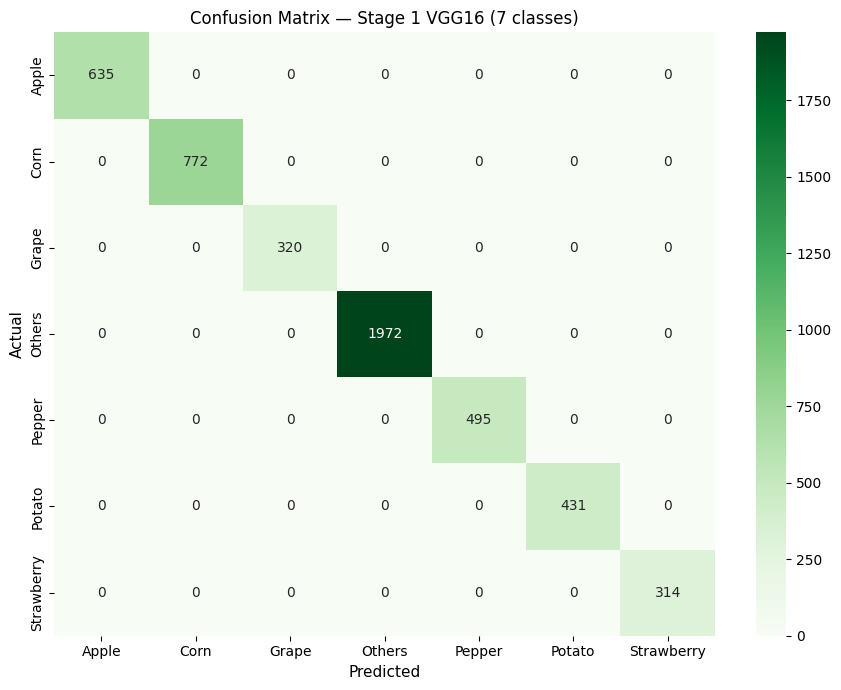


⚠  Check the 'Others' row:
   High recall on Others = model reliably rejects non-leaf images.


In [12]:
# ══════════════════════════════════════════════════════════════════════
# STEP 9  —  Per-class accuracy report + confusion matrix
# ══════════════════════════════════════════════════════════════════════

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

valid_data.reset()
y_pred_probs = best_model.predict(valid_data, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = valid_data.classes
class_labels = list(valid_data.class_indices.keys())

print("\n" + "=" * 60)
print("  PER-CLASS ACCURACY REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_labels, yticklabels=class_labels, ax=ax
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual',    fontsize=11)
ax.set_title('Confusion Matrix — Stage 1 VGG16 (7 classes)', fontsize=12)
plt.tight_layout()
plt.savefig('stage1_confusion_matrix.png', dpi=150)
plt.show()

print("\n⚠  Check the 'Others' row:")
print("   High recall on Others = model reliably rejects non-leaf images.")

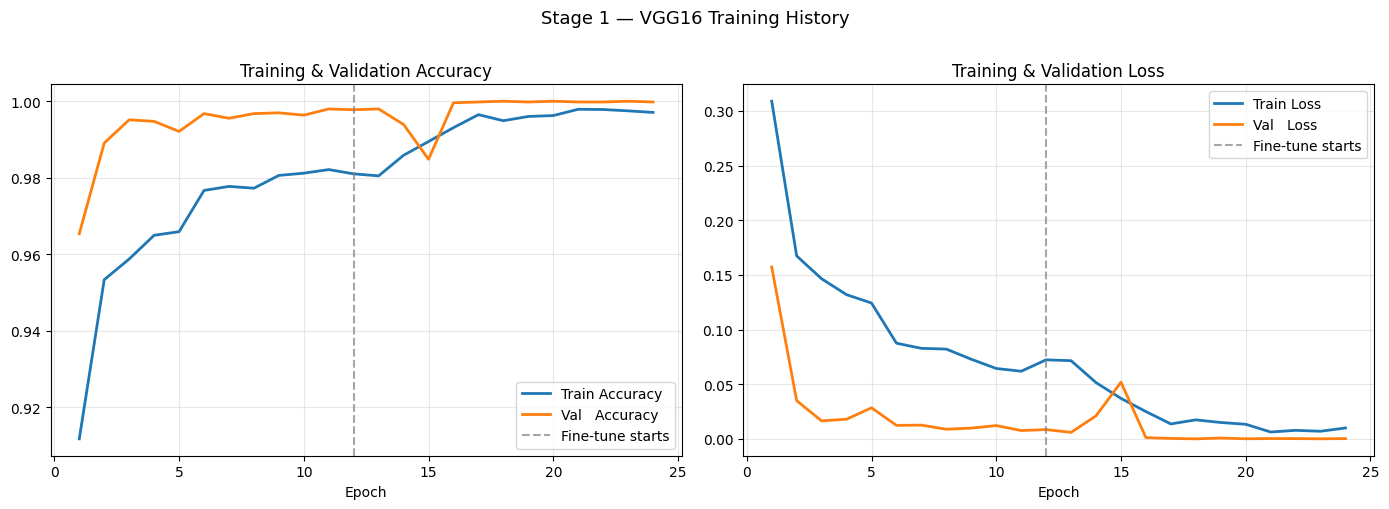

Plot saved as stage1_training_history.png


In [13]:
# ══════════════════════════════════════════════════════════════════════
# STEP 10  —  Training history plot
# ══════════════════════════════════════════════════════════════════════

def _join(h1, h2, key):
    return h1.history[key] + h2.history[key]

train_acc  = _join(history_phase1, history_phase2, 'accuracy')
val_acc    = _join(history_phase1, history_phase2, 'val_accuracy')
train_loss = _join(history_phase1, history_phase2, 'loss')
val_loss   = _join(history_phase1, history_phase2, 'val_loss')
phase1_end = len(history_phase1.history['accuracy'])
epochs_rng = range(1, len(train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in zip(
    axes,
    [train_acc,  train_loss],
    [val_acc,    val_loss],
    ['Accuracy', 'Loss']
):
    ax.plot(epochs_rng, tr, label=f'Train {title}', linewidth=2)
    ax.plot(epochs_rng, vl, label=f'Val   {title}', linewidth=2)
    ax.axvline(x=phase1_end, color='gray', linestyle='--',
               alpha=0.7, label='Fine-tune starts')
    ax.set_title(f'Training & Validation {title}')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Stage 1 — VGG16 Training History', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('stage1_training_history.png', dpi=150)
plt.show()
print('Plot saved as stage1_training_history.png')

In [14]:
# ══════════════════════════════════════════════════════════════════════
# STEP 11  —  Save final model + class map
# ══════════════════════════════════════════════════════════════════════

best_model.save('stage1_plant_identifier_vgg16.keras')

# class_indices.json was already saved in Step 2, but re-save to be safe
with open('stage1_class_indices.json', 'w') as f:
    json.dump(train_data.class_indices, f, indent=2)

print('✅ Saved files:')
print('   stage1_plant_identifier_vgg16.keras      — final model')
print('   stage1_plant_identifier_best.keras       — best checkpoint')
print('   stage1_class_indices.json                — class map (required for inference)')
print()
print('Class order:')
for name, idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    print(f'  [{idx}] {name}')

✅ Saved files:
   stage1_plant_identifier_vgg16.keras      — final model
   stage1_plant_identifier_best.keras       — best checkpoint
   stage1_class_indices.json                — class map (required for inference)

Class order:
  [0] Apple
  [1] Corn
  [2] Grape
  [3] Others
  [4] Pepper
  [5] Potato
  [6] Strawberry
